# Setup and Imports


In [2]:
%load_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Add src folder to the path
sys.path.append(os.path.abspath('../src'))

from data_utils import load_bitstream, apply_error_correction
from modulator import (
    apply_tukey_window,
    map_bits_to_qam,
    normalize_audio,
    pulse_shape_symbols,
    to_int16_pcm,
    upconvert_to_passband,
)
from plot_utils import plot_complex_parts, plot_fft, plot_waveform
from sync import assemble_baseband_frame, generate_zadoff_chu_audio


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# System Parameters


In [3]:
FS = 48000             # Sample rate (Hz)
F_CARRIER = 10000      # Center frequency (10 kHz is safely in your 2-18kHz window)

# Start conservative to test the channel, then increase for more points!
SYMBOL_RATE = 7000     # Symbols per second (Baud)

# Calculate how many audio samples represent one symbol
# 48000 Hz / 7000 Baud = 6.86 samples per symbol
SAMPLES_PER_SYMBOL = FS // SYMBOL_RATE

print(f"Carrier Frequency: {F_CARRIER} Hz")
print(f"Symbol Rate: {SYMBOL_RATE} Baud")
print(f"Samples per Symbol: {SAMPLES_PER_SYMBOL}")
print(f"Main Lobe Bandwidth: ~{2 * SYMBOL_RATE} Hz (From {F_CARRIER - SYMBOL_RATE} Hz to {F_CARRIER + SYMBOL_RATE} Hz)")


Carrier Frequency: 10000 Hz
Symbol Rate: 7000 Baud
Samples per Symbol: 6
Main Lobe Bandwidth: ~14000 Hz (From 3000 Hz to 17000 Hz)


# QAM Modulation


In [4]:
# --- TOY MODEL CONFIGURATION ---
M = 4  # Change to 4, 16, 64, or 256
bits_per_symbol = int(np.log2(M))

# Let's generate enough bits for few symbols
total_bits = 5000 * bits_per_symbol

input_path = "../data/message.txt"  # need to make a program which converts the message to bits
read_flag = False

if read_flag:
    if not os.path.exists(input_path):
        raise FileNotFoundError("message.txt not found")

    with open(input_path, "r") as f:
        content = f.read().strip()

    if len(content) == 0:
        raise ValueError("File is empty. Cannot read message bits.")

    message_bits = np.array(list(map(int, content)))
else:
    message_bits = np.random.randint(0, 2, total_bits)

    with open(input_path, "w") as f:
        f.write("".join(map(str, message_bits)))

qam_symbols = map_bits_to_qam(message_bits, M)
print(f"Generated {len(qam_symbols)} complex symbols for {M}-QAM.")


Generated 5000 complex symbols for 4-QAM.


# Baseband Pulse Shaping, Pilots, and Frame Assembly


In [5]:
baseband_signal = pulse_shape_symbols(qam_symbols, SAMPLES_PER_SYMBOL)

len_zadoff_chu = 353
u_zadoff_chu = 7
sync_audio = generate_zadoff_chu_audio(len_zadoff_chu, u_zadoff_chu)

NUM_PILOTS = 16
pilot_bits = [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0]
pilot_symbols = map_bits_to_qam(pilot_bits, M)
pilot_symbols


array([-0.70710678+0.70710678j,  0.70710678-0.70710678j,
       -0.70710678+0.70710678j,  0.70710678-0.70710678j,
       -0.70710678+0.70710678j,  0.70710678-0.70710678j,
       -0.70710678+0.70710678j,  0.70710678-0.70710678j])

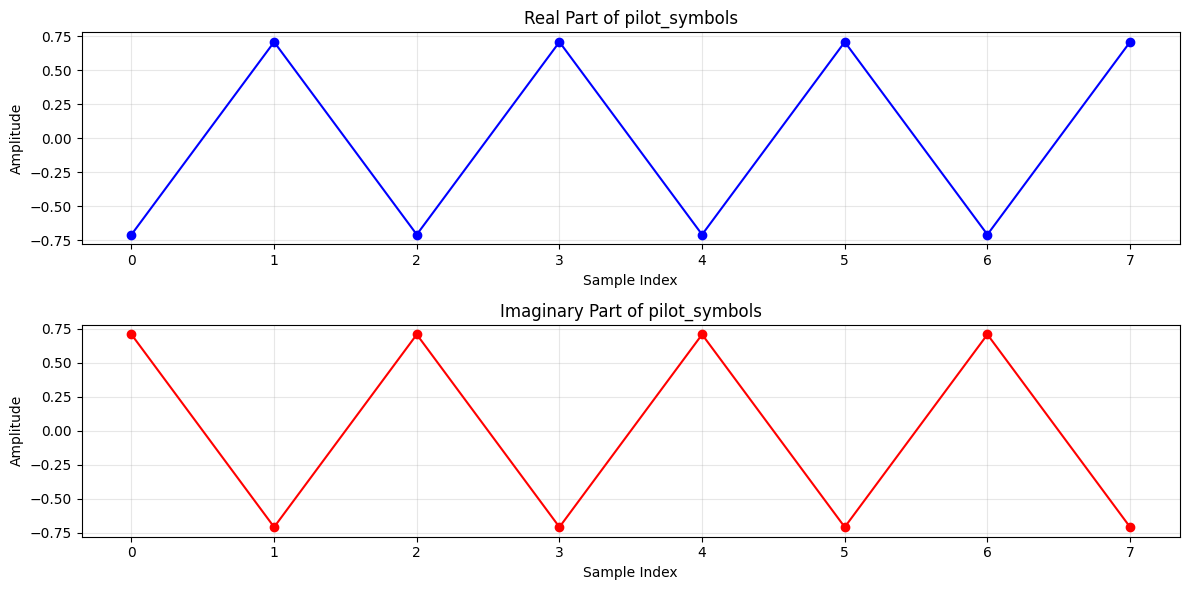

In [6]:
plot_complex_parts(pilot_symbols, title_prefix="pilot_symbols")
plt.show()


In [7]:
pilot_signal = pulse_shape_symbols(pilot_symbols, SAMPLES_PER_SYMBOL)

baseband_transmission = assemble_baseband_frame(
    sync_audio=sync_audio,
    pilot_signal=pilot_signal,
    payload_signal=baseband_signal,
    fs=FS,
    start_silence=5.0,
    middle_silence=0.05,
    end_silence=5.0,
)


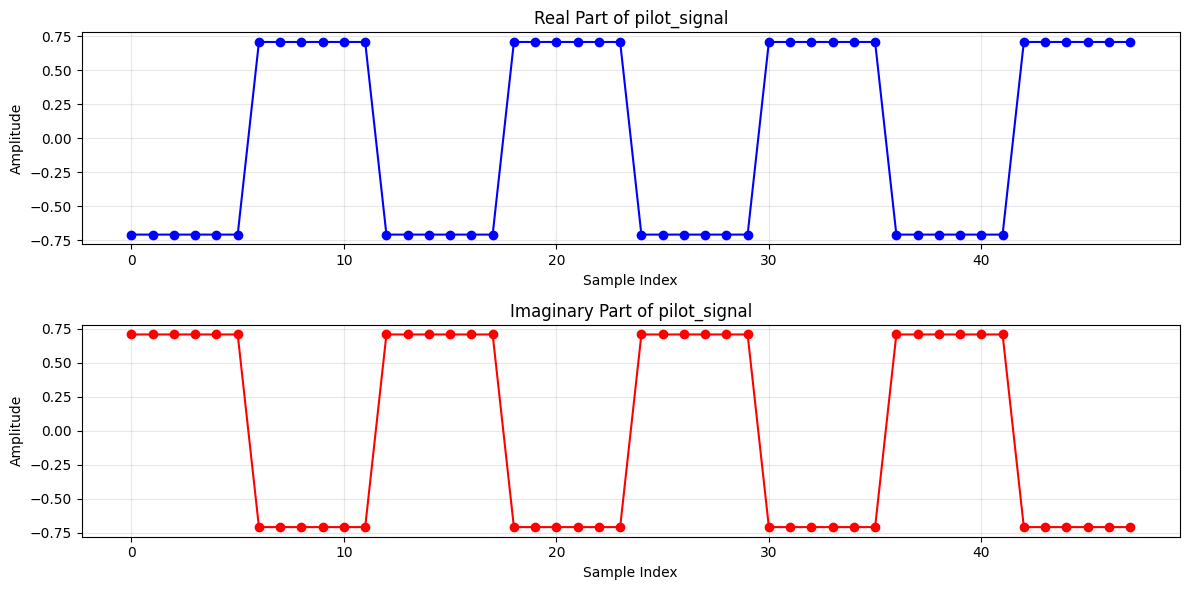

In [8]:
plot_complex_parts(pilot_signal, title_prefix="pilot_signal")
plt.show()


# Passband Modulation and WAV Export


Data payload successfully modulated to passband audio.
Saved transmission file to: ../data/tx_single_carrier_test.wav


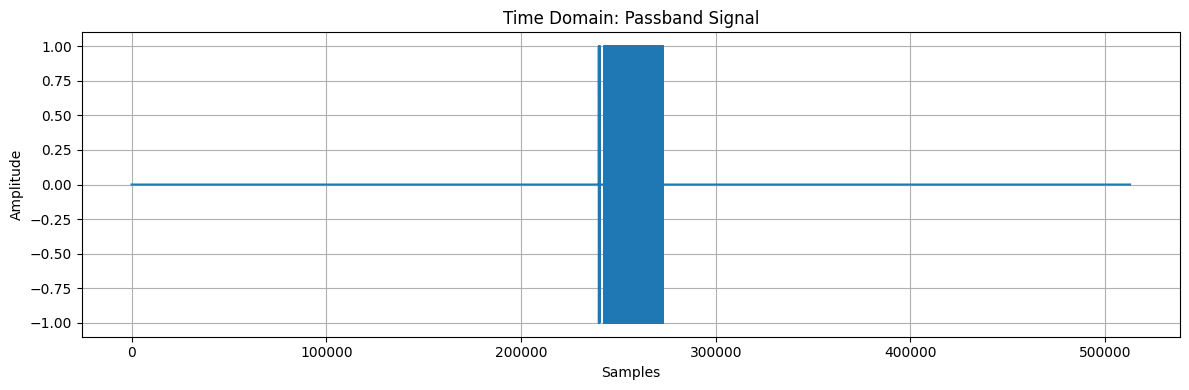

In [9]:
passband_signal = upconvert_to_passband(baseband_transmission, FS, F_CARRIER)
transmission_signal = apply_tukey_window(passband_signal, alpha=0.01)
print("Data payload successfully modulated to passband audio.")

transmission_signal = normalize_audio(transmission_signal)
transmission_signal_16bit = to_int16_pcm(transmission_signal)

output_path = "../data/tx_single_carrier_test.wav"
wavfile.write(output_path, FS, transmission_signal_16bit)
print(f"Saved transmission file to: {output_path}")

plot_waveform(passband_signal, title="Time Domain: Passband Signal")
plt.show()


# Quick Checks


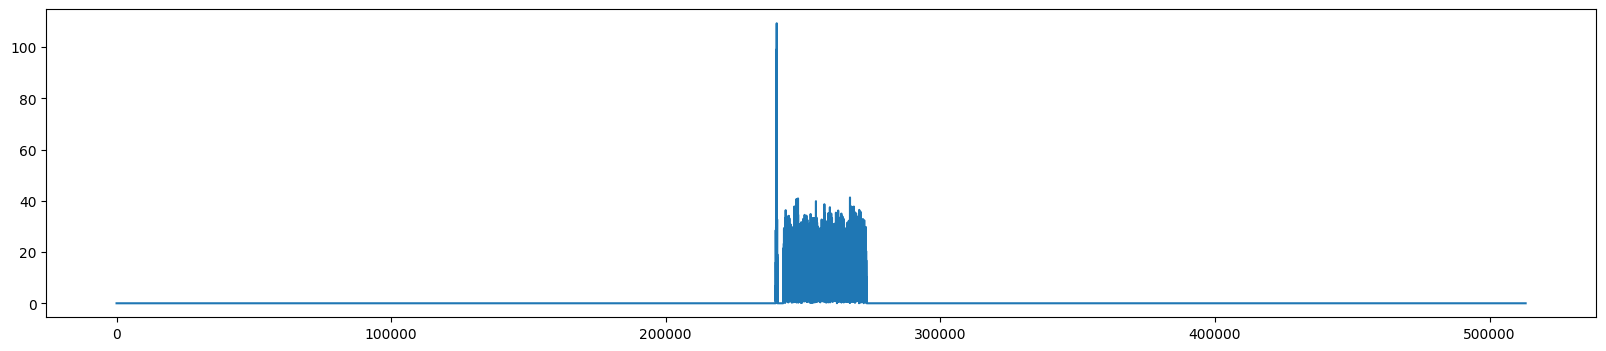

In [10]:
r = corr = np.correlate(passband_signal, sync_audio, mode="full")
plt.figure(figsize=(20, 4))
plt.plot(abs(corr))
plt.show()


512801


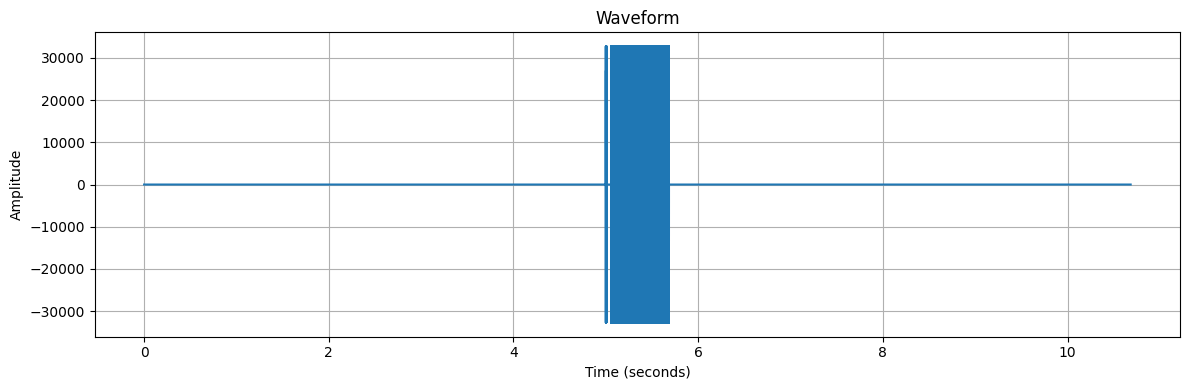

In [11]:
sample_rate, data = wavfile.read("../data/tx_single_carrier_test.wav")
print(len(data))
plot_waveform(data, sample_rate=sample_rate, title="Waveform")
plt.show()


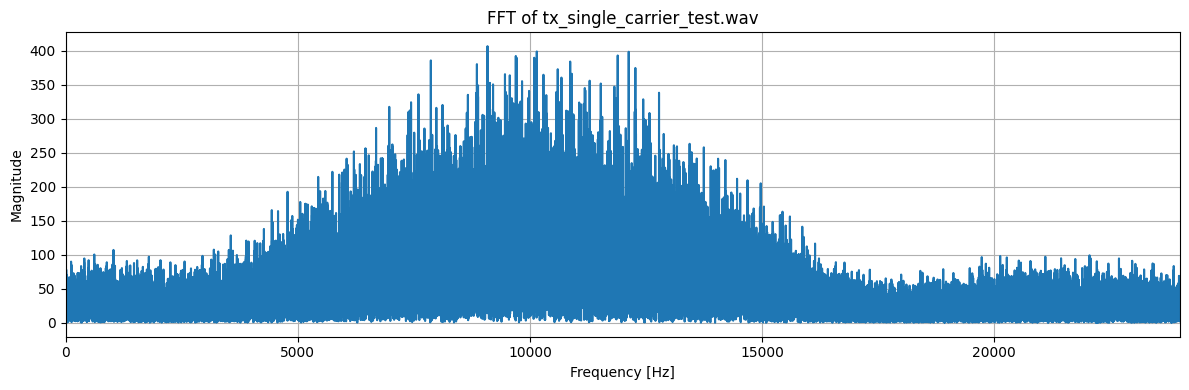

In [12]:
fs_read, audio_data = wavfile.read(output_path)
plot_fft(audio_data, fs_read, title="FFT of tx_single_carrier_test.wav")
plt.show()


c:\Users\Ishaan\Ishaan\IITM\Sem6\CommSys\Project\transceiver-project\venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Ishaan\Ishaan\IITM\Sem6\CommSys\Project\transceiver-project\venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


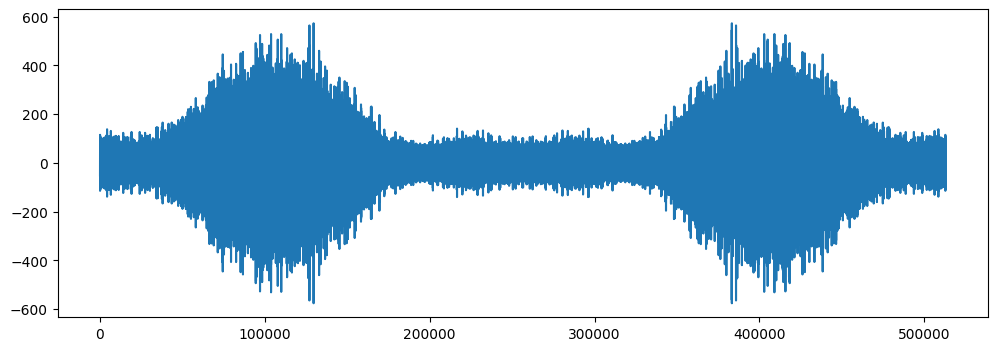

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(np.fft.fft(passband_signal))
plt.show()
